<a href="https://colab.research.google.com/github/Annamalag/PI_Mineria_Datos_1-/blob/main/Notebooks/03_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set(style="whitegrid", palette="Set2")


# **Objetivo del EDA**

Analizar las características de los usuarios de la plataforma, identificando patrones de consumo, diferencias entre planes de suscripción y posibles relaciones entre las variables demográficas y de uso.

In [2]:
df = pd.read_csv("/content/cleaned_dataset.csv")

In [3]:
df.head()

,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39.0,Estandar,805.8,Brasil,Crimen,2025-03-04,99
1,10001,37.0,Estandar,1173.4,Colombia,Crimen,2019-04-02,2
2,10002,28.0,Basico,401.0,Colombia,Crimen,2018-04-13,0
3,10003,43.0,Basico,62.4,Uruguay,Thriller,2021-01-31,0
4,10004,51.0,Basico,477.8,Peru,Thriller,2020-09-30,1


In [4]:
df.isnull().sum()

,0
user_id,0
age,0
subscription_plan,0
monthly_watch_time_mins,0
country,0
favorite_genre,0
last_login_date,0
customer_support_tickets,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8034 entries, 0 to 8033
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   8034 non-null   int64  
 1   age                       8034 non-null   float64
 2   subscription_plan         8034 non-null   object 
 3   monthly_watch_time_mins   8034 non-null   float64
 4   country                   8034 non-null   object 
 5   favorite_genre            8034 non-null   object 
 6   last_login_date           8034 non-null   object 
 7   customer_support_tickets  8034 non-null   int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 502.3+ KB


# **Analisis Univariado**

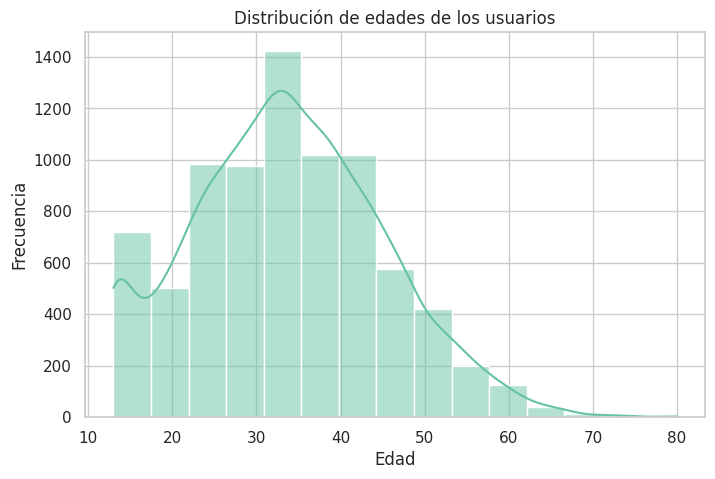

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="age",
    bins=15,
    kde=True
)

plt.title("Distribución de edades de los usuarios")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()

### Interpretación

La distribución de edades permite identificar el rango etario predominante de los usuarios de la plataforma.

La mayor concentración de usuarios se encuentra entre los **25 y 45 años**, mientras que los extremos presentan menor frecuencia. La distribución no muestra una asimetría excesiva, lo que indica una muestra relativamente equilibrada.

# **Visualización 2 (Univariada)** **Planes de suscripción (Barplot)**

La distribución de los planes permite identificar cuál concentra la mayor cantidad de usuarios. Esta información es útil para comprender la preferencia de los clientes y evaluar el nivel de adopción de cada modalidad de suscripción.

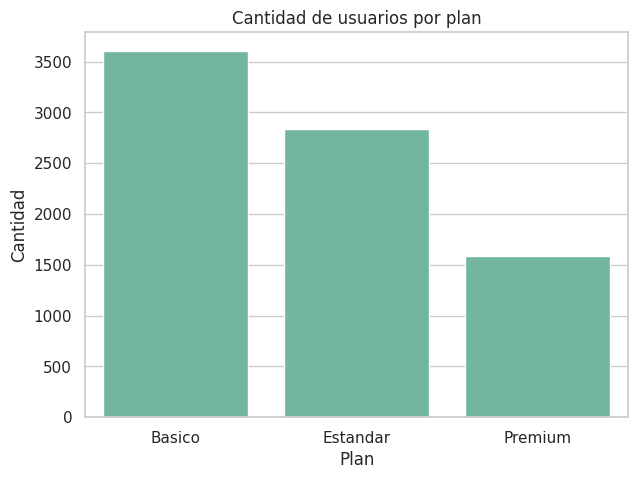

In [7]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="subscription_plan",
    order=df["subscription_plan"].value_counts().index
)

plt.title("Cantidad de usuarios por plan")
plt.xlabel("Plan")
plt.ylabel("Cantidad")

plt.show()

### Interpretación

El gráfico muestra la distribución de usuarios según el tipo de suscripción.

El plan más contratado es el **Basico** , seguido del Estandar y por ultimo el Premium.


# **Visualización 3 (Bivariada): Plan vs Tiempo de visualización (Boxplot)**

# **Pregunta**

**¿Los usuarios Premium consumen más contenido que los usuarios de otros planes?**

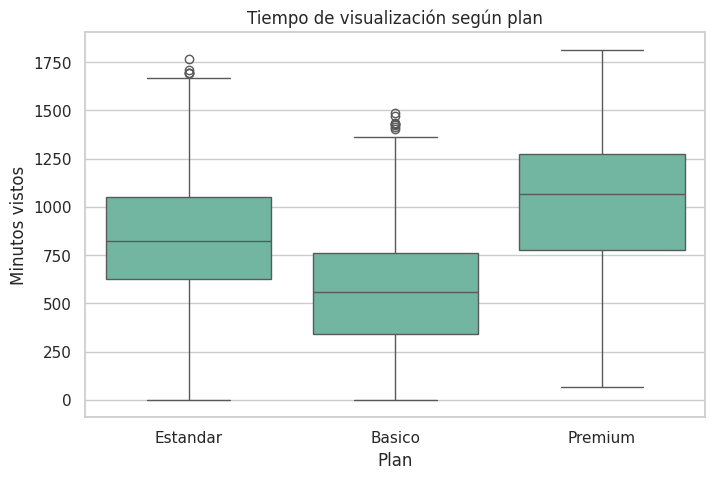

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="subscription_plan",
    y="monthly_watch_time_mins"
)

plt.title("Tiempo de visualización según plan")
plt.xlabel("Plan")
plt.ylabel("Minutos vistos")

plt.show()

### Interpretación

El diagrama de cajas permite comparar la distribución del tiempo de visualización entre los distintos planes de suscripción.

Se observa si los usuarios de planes superiores presentan un mayor consumo de contenido y si existen diferencias en la dispersión de los datos.

El gráfico muestra que existe una relación entre el plan de suscripción y el tiempo de visualización mensual. Los usuarios del plan Premium presentan la mediana más alta de minutos vistos, lo que indica que, en general, consumen más contenido que los usuarios de los demás planes. Por el contrario, los usuarios del plan Básico registran el menor tiempo de visualización, mientras que el plan Estándar presenta un comportamiento intermedio.

Además, se observa una mayor dispersión en los planes Premium y Estándar, lo que evidencia una mayor variabilidad en los hábitos de consumo de estos usuarios.

Los usuarios con planes de mayor categoría tienden a utilizar más la plataforma. Esto podría indicar que quienes invierten en un plan Premium obtienen un mayor aprovechamiento del servicio o que los usuarios con un mayor nivel de consumo son quienes optan por planes más completo.

# **Visualización 4 (Bivariada) Edad vs consumo**

# **Pregunta**

**¿Existe relación entre la edad y el tiempo de visualización?**

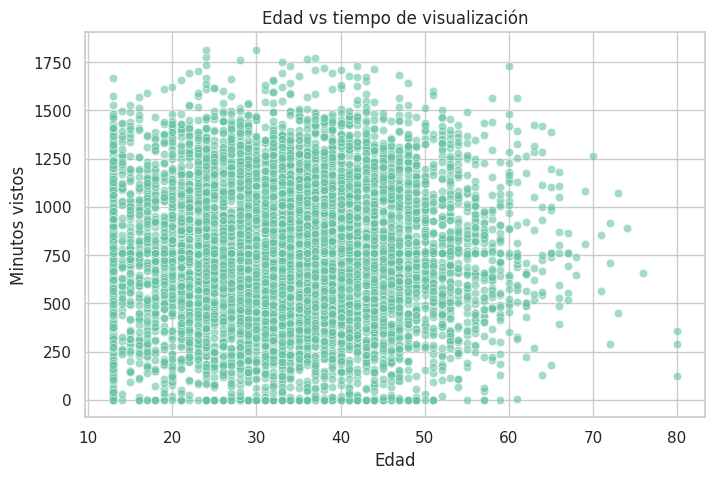

In [9]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="age",
    y="monthly_watch_time_mins",
    alpha=0.6
)

plt.title("Edad vs tiempo de visualización")
plt.xlabel("Edad")
plt.ylabel("Minutos vistos")

plt.show()

El gráfico de dispersión permite analizar si existe una relación entre la edad de los usuarios y el tiempo de visualización mensual. Se observa que los puntos están distribuidos de forma dispersa y no siguen una tendencia claramente ascendente ni descendente, lo que sugiere que la edad no presenta una relación fuerte con la cantidad de minutos vistos.

La mayor concentración de usuarios se encuentra aproximadamente entre los 20 y 50 años, con tiempos de visualización muy variados. Esto indica que, dentro de ese rango de edad, existen tanto usuarios con bajo consumo como usuarios con un consumo elevado de contenido. Asimismo, en edades más avanzadas se observa una menor cantidad de usuarios, aunque también presentan diferentes niveles de consumo.

En relación con el objetivo del análisis:la evidencia sugiere que la edad, por sí sola, no es un factor determinante del tiempo de visualización. Esto indica que otros factores, como el plan de suscripción, las preferencias de contenido o el comportamiento individual de los usuarios, podrían tener una mayor influencia sobre el consumo de la plataforma.

# **Visualización 5 (Multivariada) Matrix de Correlacion**

# **Pregunta:**

**¿Existe una relación lineal entre variables numéricas(la edad de los usuarios, el tiempo de visualización mensual y la cantidad de tickets de soporte generados?)**

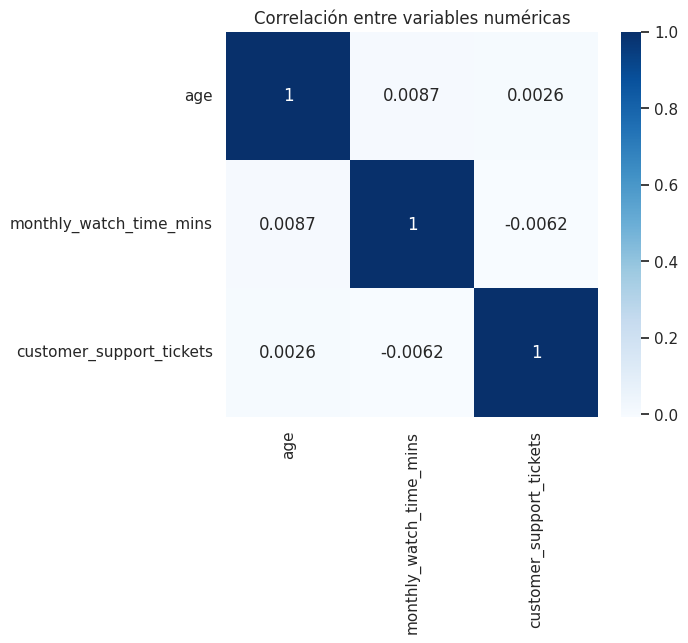

In [11]:
plt.figure(figsize=(6,5))

corr = df[
    ["age",
     "monthly_watch_time_mins",
     "customer_support_tickets"]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues"
)

plt.title("Correlación entre variables numéricas")

plt.show()

**no existe una relación lineal significativa entre las variables**

La matriz de correlación muestra que las variables numéricas analizadas (edad, tiempo de visualización mensual y cantidad de tickets de soporte) presentan coeficientes de correlación muy cercanos a cero. En particular, la relación entre la edad y el tiempo de visualización es de 0,0087, entre la edad y los tickets de soporte es de 0,0026, y entre el tiempo de visualización y los tickets de soporte es de -0,0062. Estos valores indican que no existe una relación lineal significativa entre estas variables.

En relación con el objetivo del proyecto, esta evidencia sugiere que ni la edad ni la cantidad de tickets de soporte permiten explicar el tiempo de visualización de los usuarios. Por lo tanto, el comportamiento de consumo de la plataforma probablemente esté influenciado por otros factores, como el plan de suscripción, las preferencias de contenido o variables que no están presentes en el conjunto de datos. Este resultado es importante porque permite descartar relaciones lineales relevantes entre las variables numéricas y orientar el análisis hacia otros factores que podrían tener un mayor impacto en los hábitos de consumo.

# **Conclusiones del Análisis Exploratorio de Datos (EDA)**

El análisis exploratorio permitió comprender mejor las características y el comportamiento de los usuarios de la plataforma de streaming. A partir de las visualizaciones realizadas, se identificaron patrones relevantes relacionados con la distribución de los usuarios, sus hábitos de consumo y la relación entre distintas variables.

En primer lugar, el análisis univariado mostró que la mayoría de los usuarios se concentra en un rango de edad intermedio y que el plan Estándar es el más utilizado dentro del conjunto de datos. Esto permite caracterizar el perfil predominante de los usuarios de la plataforma.

Por otro lado, el análisis bivariado evidenció que el plan de suscripción influye en el tiempo de visualización mensual. Los usuarios del plan Premium presentan, en general, una mayor cantidad de minutos vistos, mientras que los usuarios del plan Básico registran el menor nivel de consumo. En cambio, la relación entre la edad y el tiempo de visualización resultó débil, ya que usuarios de distintas edades presentan comportamientos de consumo muy variados.

En el análisis multivariado se observó que las correlaciones entre las variables numéricas (edad, tiempo de visualización y cantidad de tickets de soporte) son prácticamente nulas, lo que indica que no existe una relación lineal significativa entre ellas. Esto sugiere que el comportamiento de los usuarios no puede explicarse únicamente por estas variables y que otros factores, como el tipo de suscripción o las preferencias de contenido, podrían tener una mayor influencia.

En conclusión, el EDA permitió identificar que el plan de suscripción es la variable que presenta una relación más evidente con el nivel de consumo de la plataforma, mientras que la edad y la cantidad de tickets de soporte no muestran asociaciones relevantes con el tiempo de visualización. Estos hallazgos aportan una base sólida para futuras etapas del proyecto, orientando el análisis hacia variables con mayor capacidad para explicar los patrones de uso y el comportamiento de los usuarios.